In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r"C:\Users\User\Documents\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [10]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [12]:
df.groupby("Outcome")["Age"].mean()

Outcome
0    31.190000
1    37.067164
Name: Age, dtype: float64

In [13]:
corr = df['Pregnancies'].corr(df['Outcome'])
print(corr)

0.22189815303398652


In [14]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


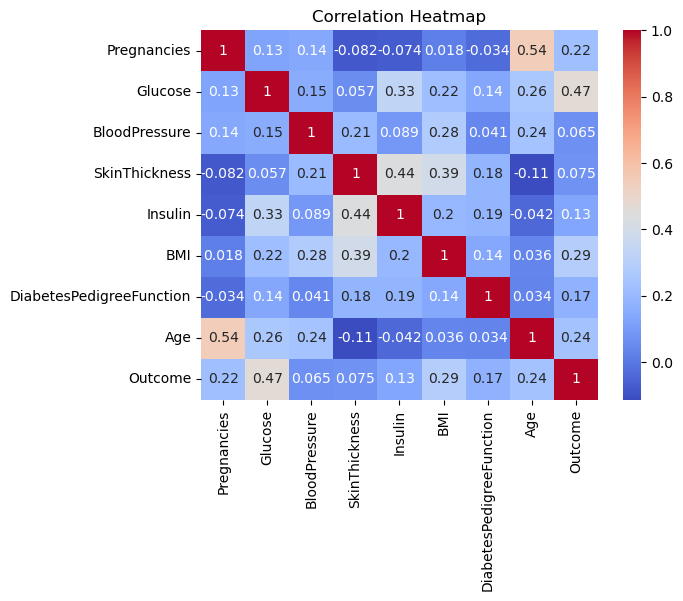

In [9]:
corr = df.corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


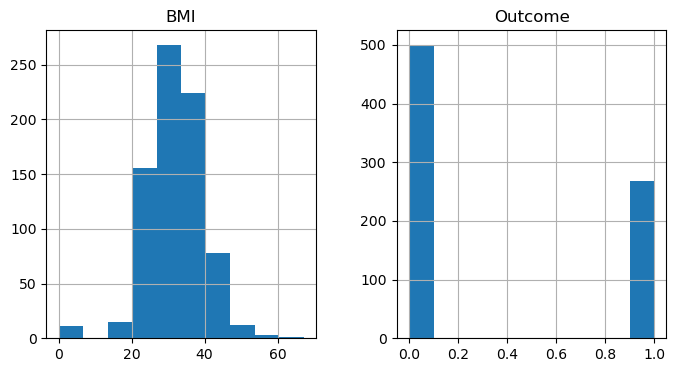

In [17]:
df[['BMI','Outcome']].hist(bins=10, figsize=(8,4))
plt.show()

Outcome
0    30.304200
1    35.142537
Name: BMI, dtype: float64

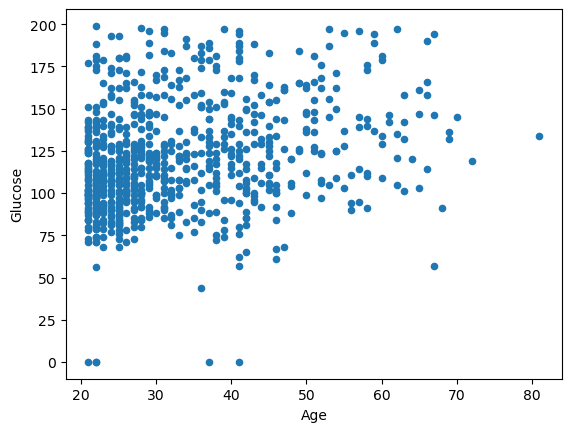

In [13]:
df.plot.scatter(x='Age', y='Glucose')
plt.show()

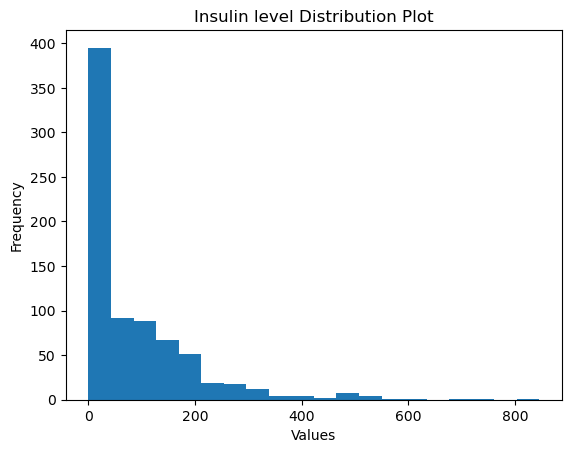

In [19]:
df['Insulin'].plot(kind='hist', bins=20)
plt.xlabel('Values')
plt.title('Insulin level Distribution Plot')
plt.show()

In [25]:
bins = [20,30,40,50,100]
labels = ['20-30','31-40','41-50','51+']
df['Age Group'] = pd.cut(df['Age'], bins=bins,labels=labels)

In [26]:
grouped = df.groupby('Age Group')

C:\Users\User\AppData\Local\Temp\ipykernel_4528\3845534358.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('Age Group')


In [27]:
prevalence = grouped['Outcome'].mean() * 100
print(prevalence)

Age Group
20-30    21.582734
31-40    48.407643
41-50    56.637168
51+      46.913580
Name: Outcome, dtype: float64


In [28]:
summary = grouped.agg(
    Total_People=('Outcome','count'),
    Diabetic_Cases=('Outcome','sum'),
    Prevalence_Percent=('Outcome',lambda x:x.mean() * 100)
)
print(summary)

           Total_People  Diabetic_Cases  Prevalence_Percent
Age Group                                                  
20-30               417              90           21.582734
31-40               157              76           48.407643
41-50               113              64           56.637168
51+                  81              38           46.913580


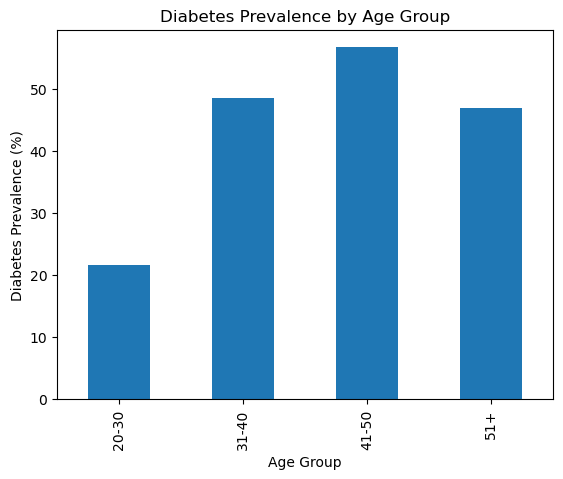

In [29]:
summary['Prevalence_Percent'].plot(kind='bar')
plt.ylabel('Diabetes Prevalence (%)')
plt.title('Diabetes Prevalence by Age Group')
plt.show()